# MFCC

In [7]:
from mffc_util import analyse_signals
import mffc_util
from importlib import reload
reload(mffc_util)

<module 'mffc_util' from '/home/igor/Desktop/MAG/1_LETNIK/2_SEMESTER/RACUNALNISKA_OBDELAVA_SIGNALOV_IN_SLIK/Vaja_7/mffc_util.py'>

## Analiza ponovljivosti vrednosti enega govorca pri isti frazi

Testna fraza: Danes je dober dan.

### Ista intonacija in hitrost izgovorjave

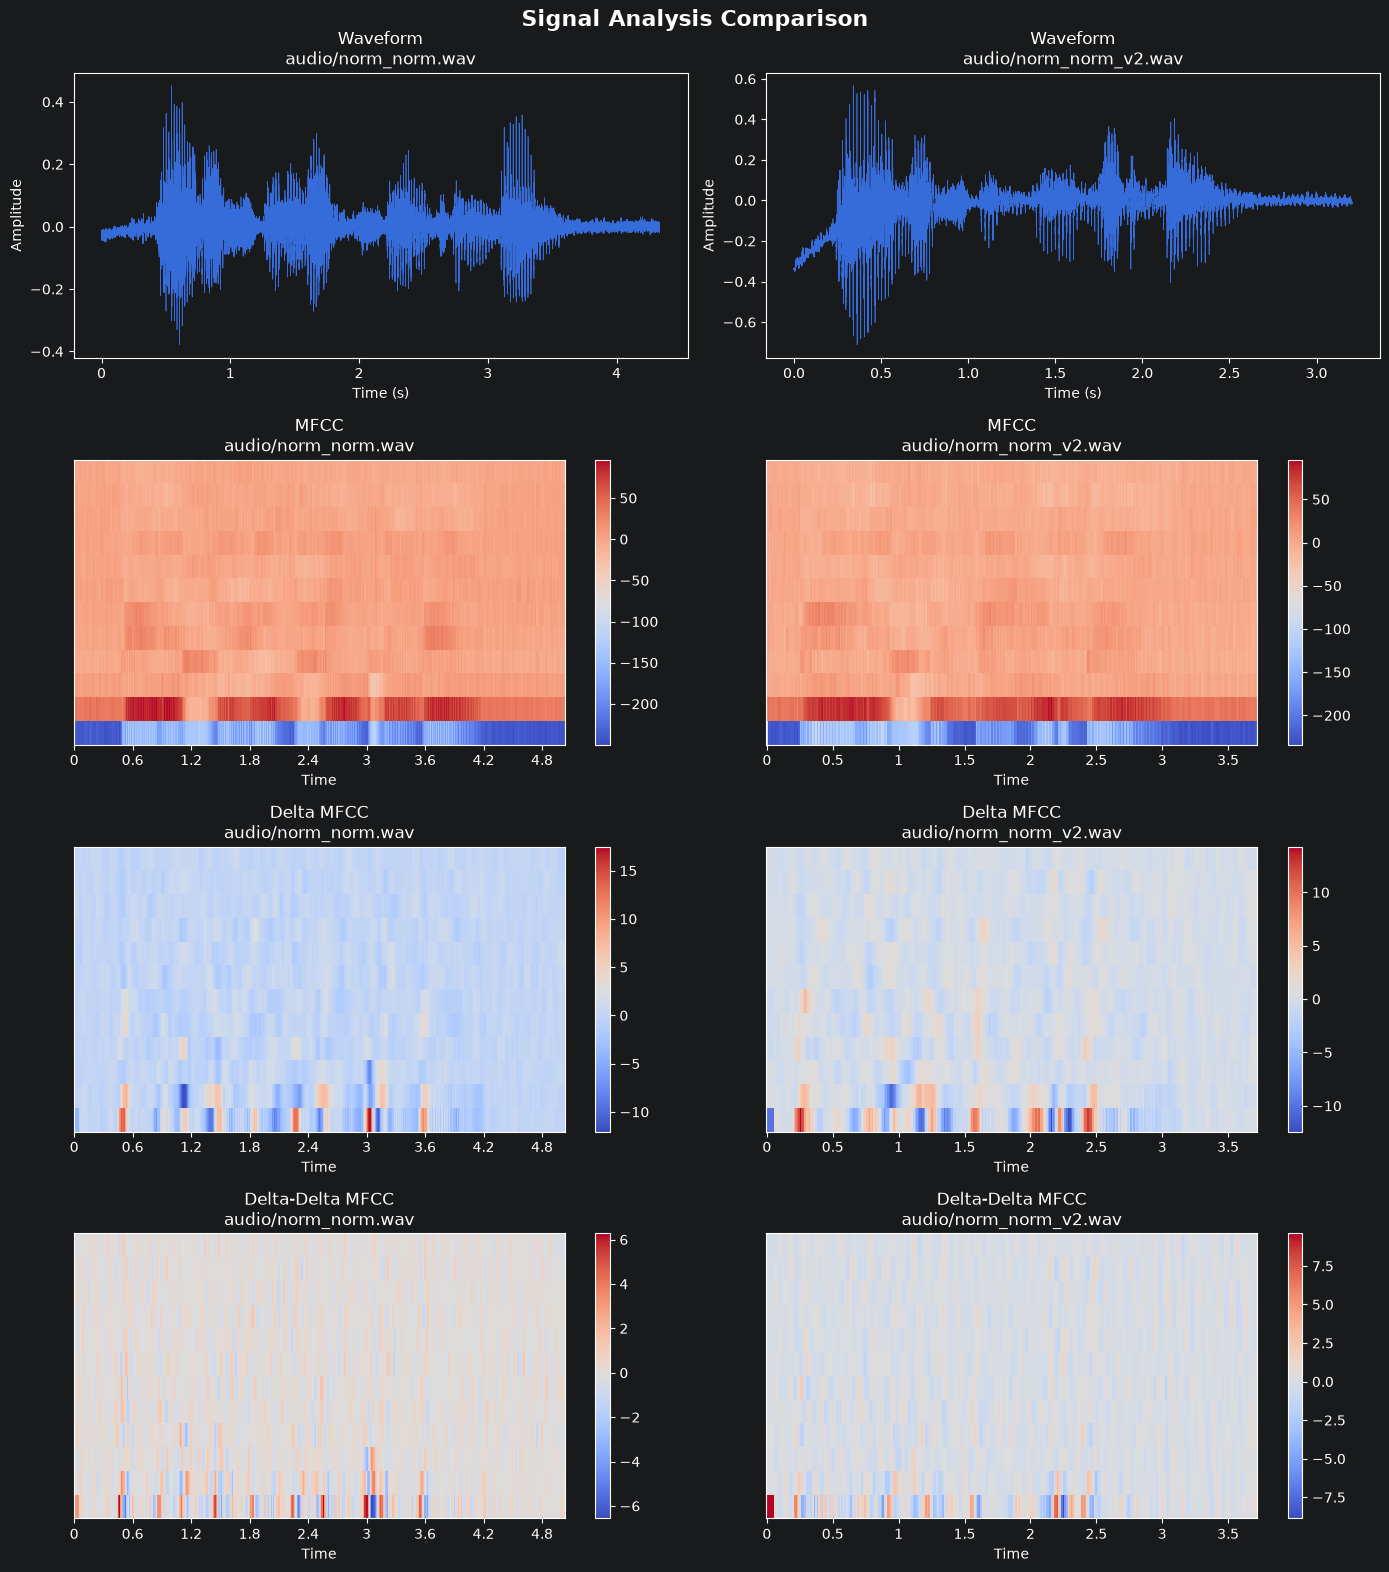

In [9]:
analyse_signals("audio/norm_norm.wav", "audio/norm_norm_v2.wav")

**Interpretacija**: Opazimo da so si pri dveh različnih posnetkih iste fraze z isto hitrostjo in intonacijo koeficienti MFCC, delta in delta-delta zelo podobni, kar potrjuje da so to dobra odrodja za razpoznavo značilk v signalih. Opazimo, da so koeficienti največji na mestih kjer se v testnem stavku pojavijo samoglasniki.

### Ista intonacija, različna hitrost izgovorjave

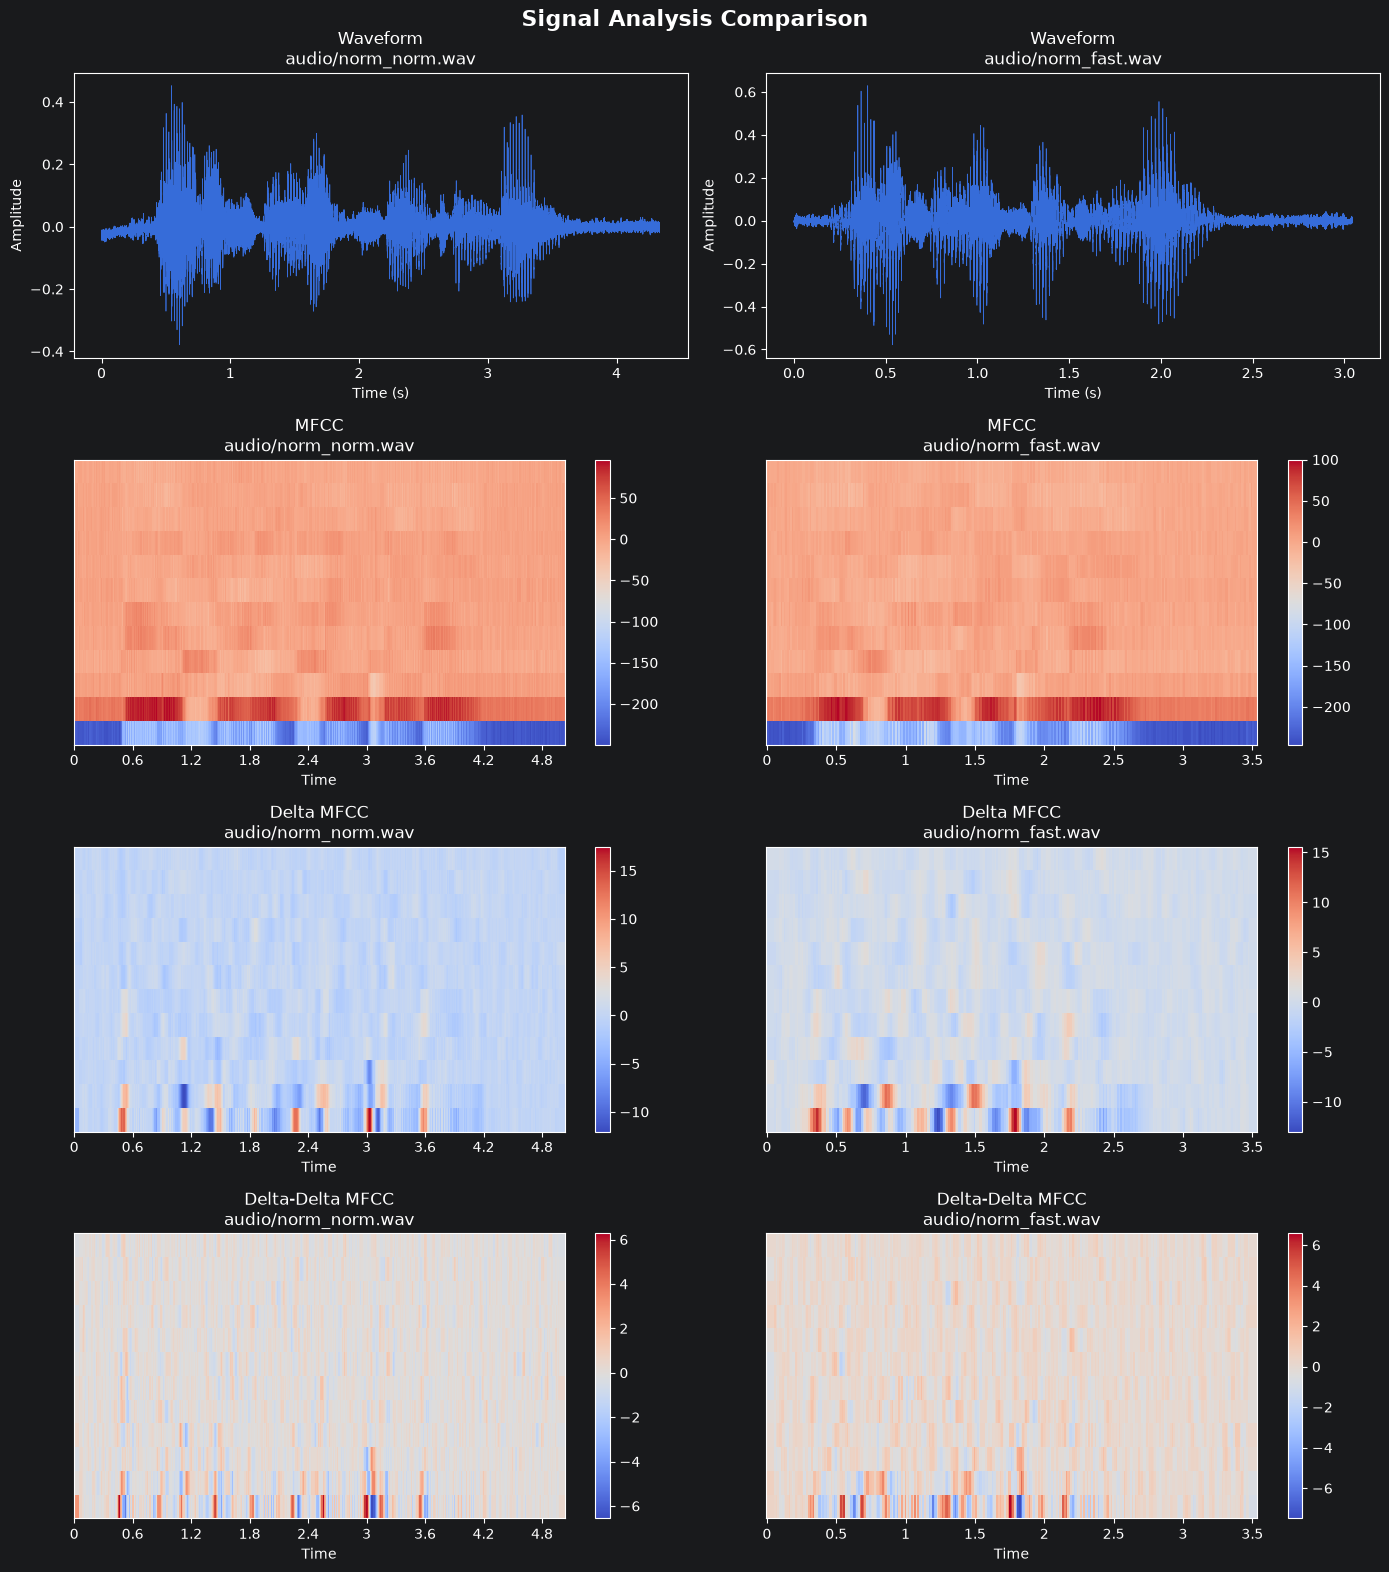

In [11]:
analyse_signals("audio/norm_norm.wav", "audio/norm_fast.wav")

**Intepretacija**: Pri posnetkih, ki se razlikujeta v hitrosti, a sta enaka v intonaciji, opazimo, da statični MFCC koeficienti ohranjajo sorazmerno isto moč (amplitudo) in zaporedje, vendar so pri hitrejši izgovorjavi časovno "stisnjeni" na krajši interval. Nasprotno pa Delta in Delta-Delta koeficienti pri hitrejši izgovorjavi pokažejo večjo moč (izrazitejše ekstreme), saj so prehodi med glasovi časovno strmejši, kar poveča vrednost odvoda.

### Različna intonacija ista hitrost izgovorjave

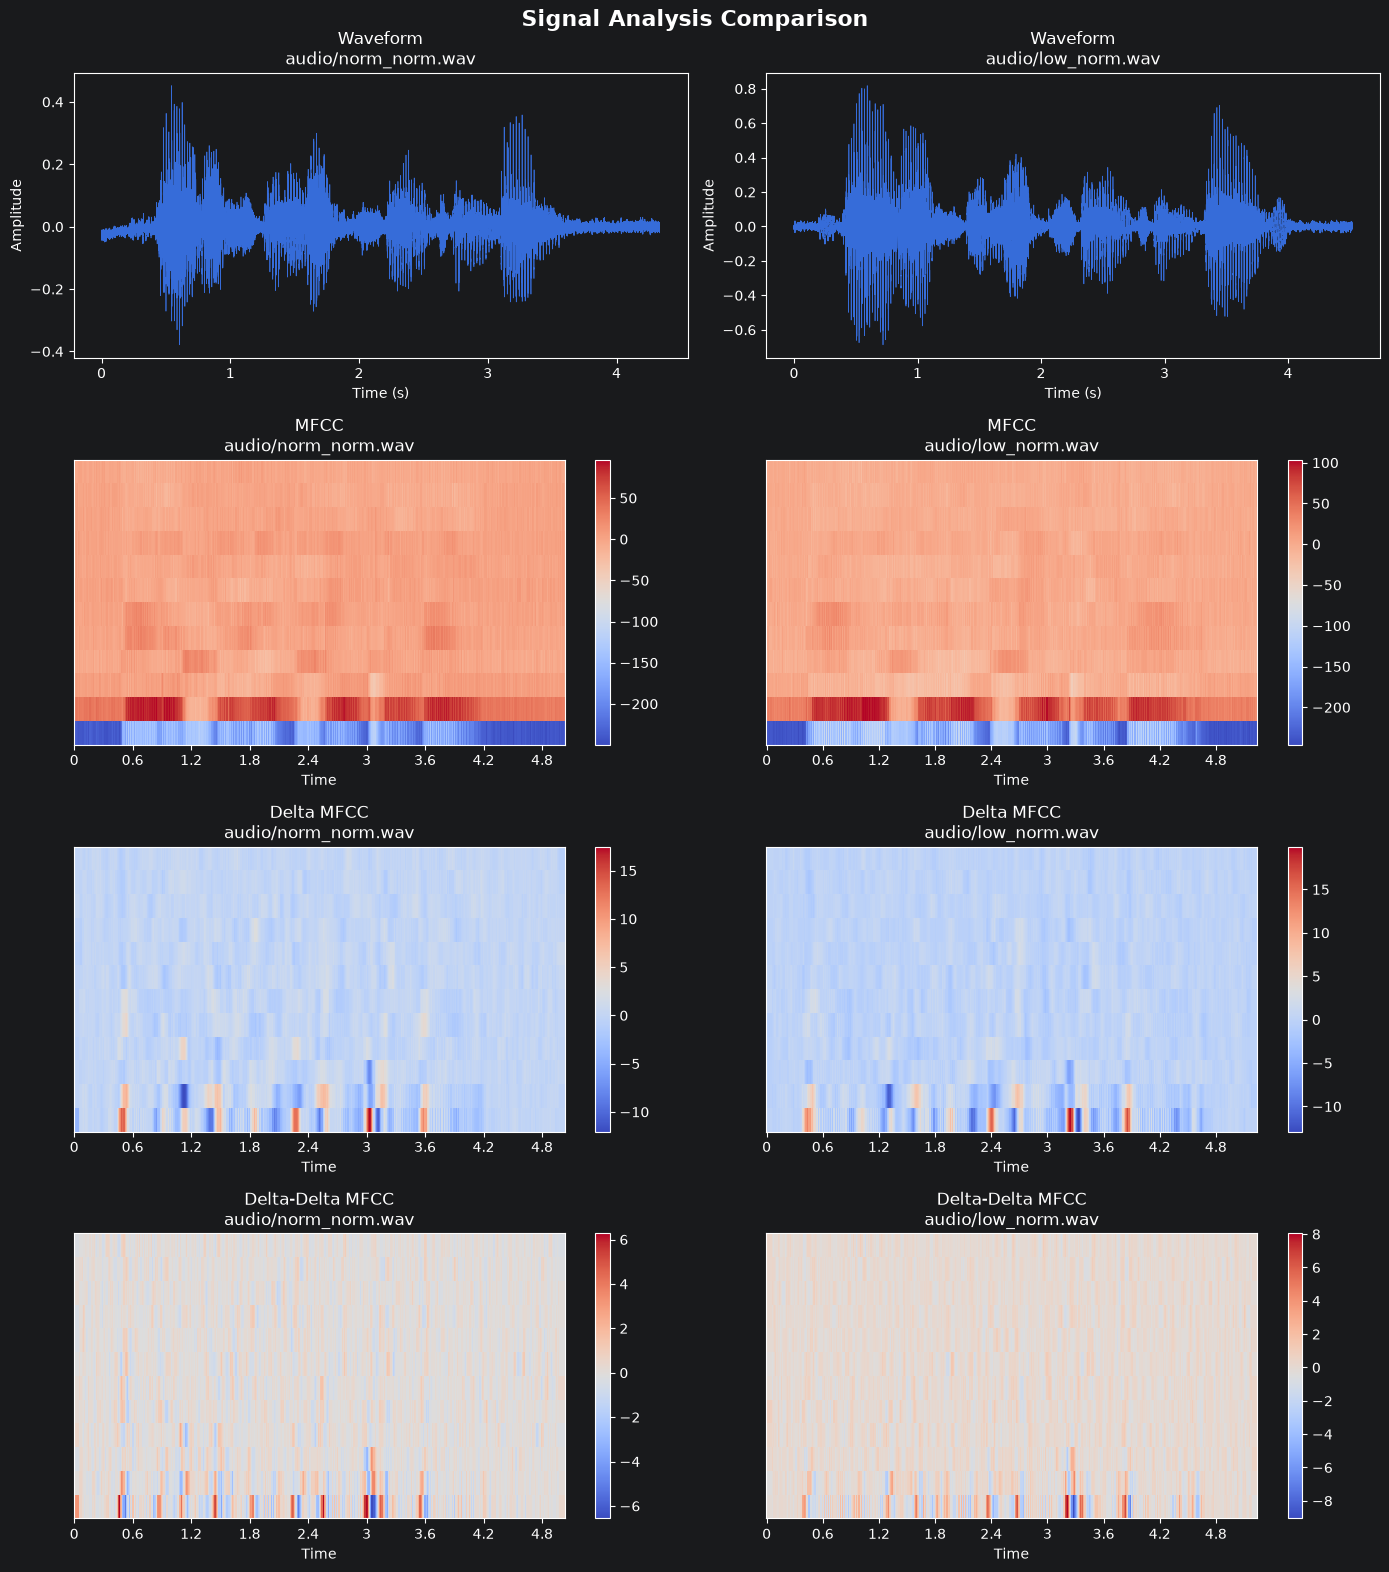

In [15]:
analyse_signals("audio/norm_norm.wav", "audio/low_norm.wav")

**Interpretacija**: Pri ponovljeni izgovorjavi iste fraze z isto hitrostjo, a različno intonacijo, opazimo, da statični MFCC koeficienti, pa tudi Delta in Delta-Delta grafi, ostajajo izjemno podobni in ponovljivi. Sprememba intonacije nima drastičnega vpliva na obliko in intenzivnost vzorcev na grafih.

To se zgodi zato, ker smo za analizo izbrali le prvih 12 MFCC koeficientov. Informacija o intonaciji (osnovna frekvenca in njeni harmoniki) se namreč po Diskretni kosinusni transformaciji (DCT) preseli izključno v visoke koeficiente kepstra, ki smo jih z izbiro parametra n_mfcc=12 odrezali in zavrgli.

Če bi želeli zaznati razlike v intonaciji, bi morali število MFCC koeficientov bistveno povečati (npr. na 50). V tem primeru bi pri posnetku z nižjo intonacijo (gostejši spektralni harmoniki) opazili izrazitejšo dinamiko in "bolj barvito" strukturo v višjih koeficientih, medtem ko bi se pri višji intonaciji ta informacija pomaknila nižje po osi koeficientov.

## Analiza ponovljivosti vrednosti enega govorca pri isti frazi


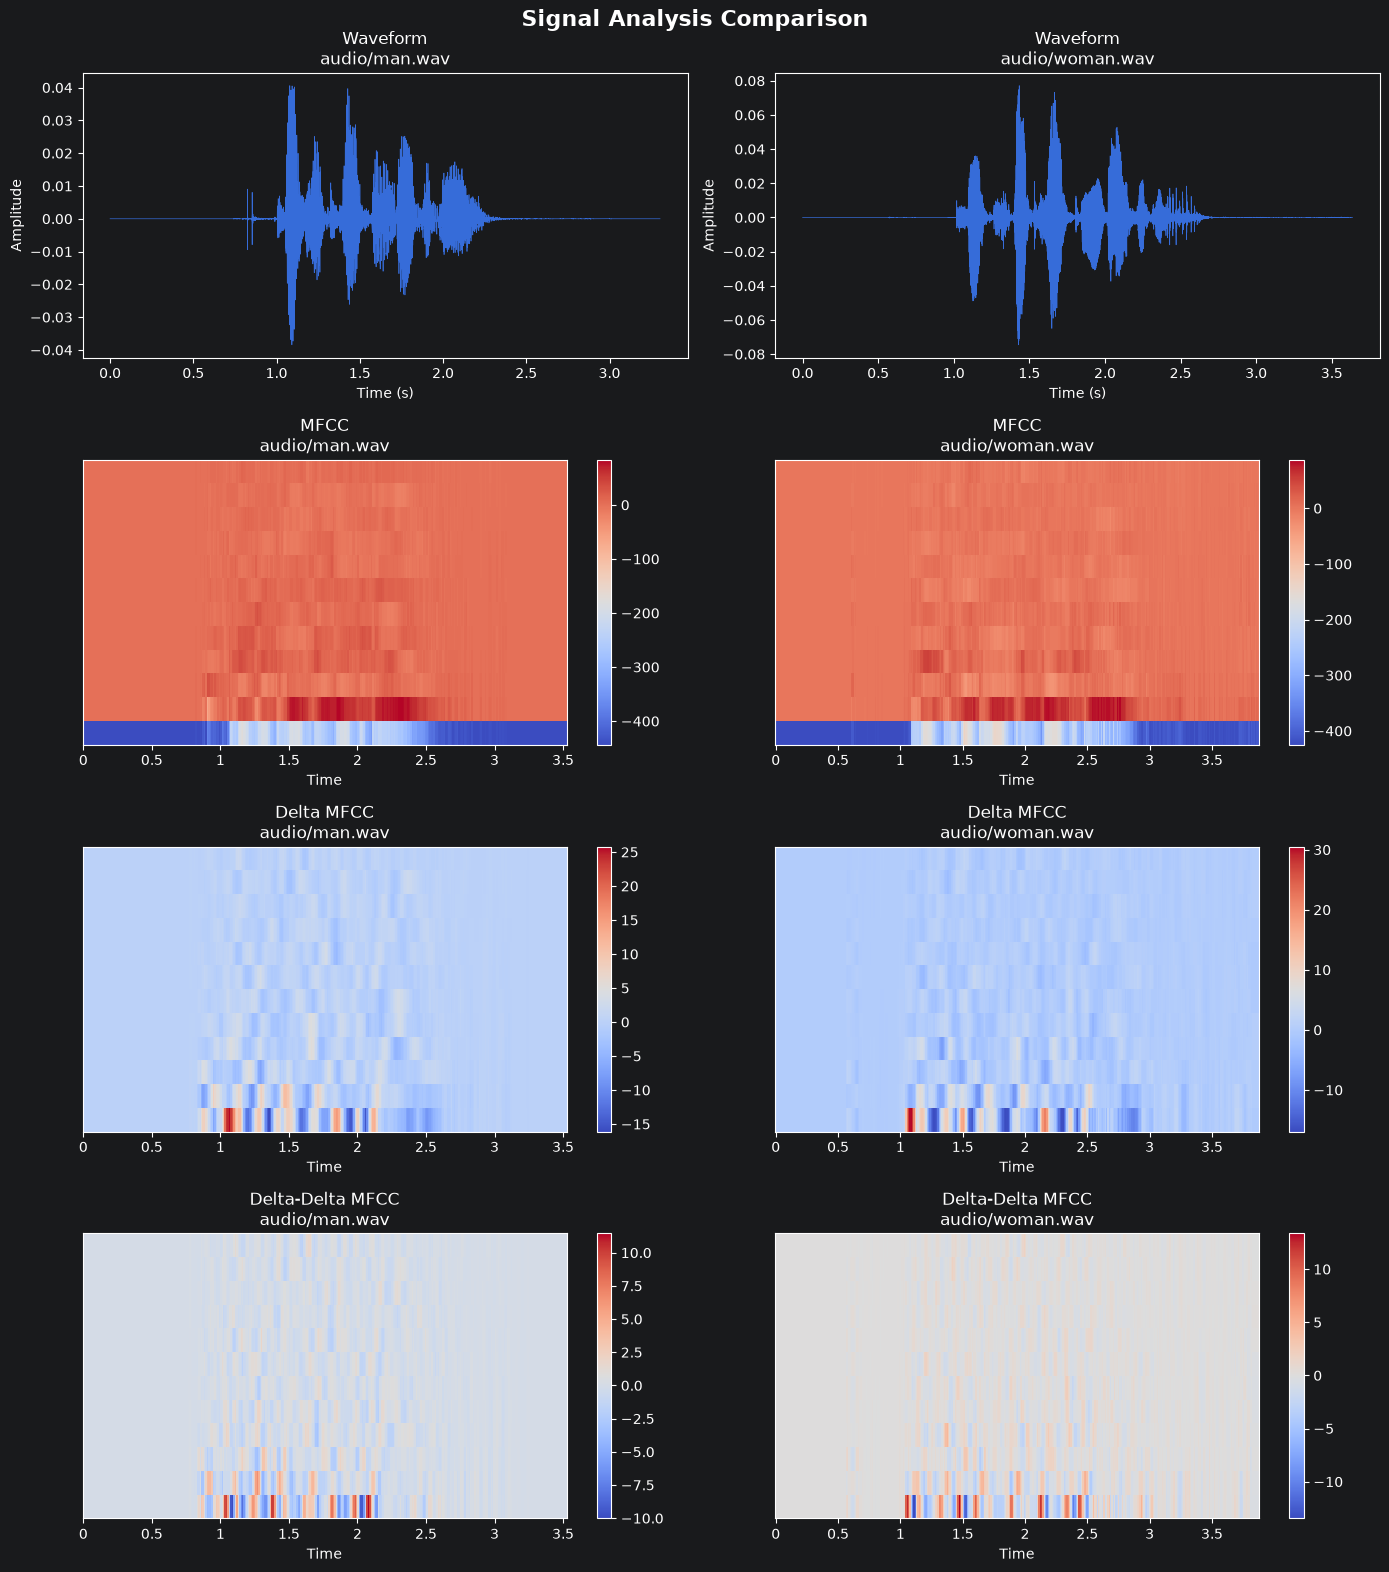

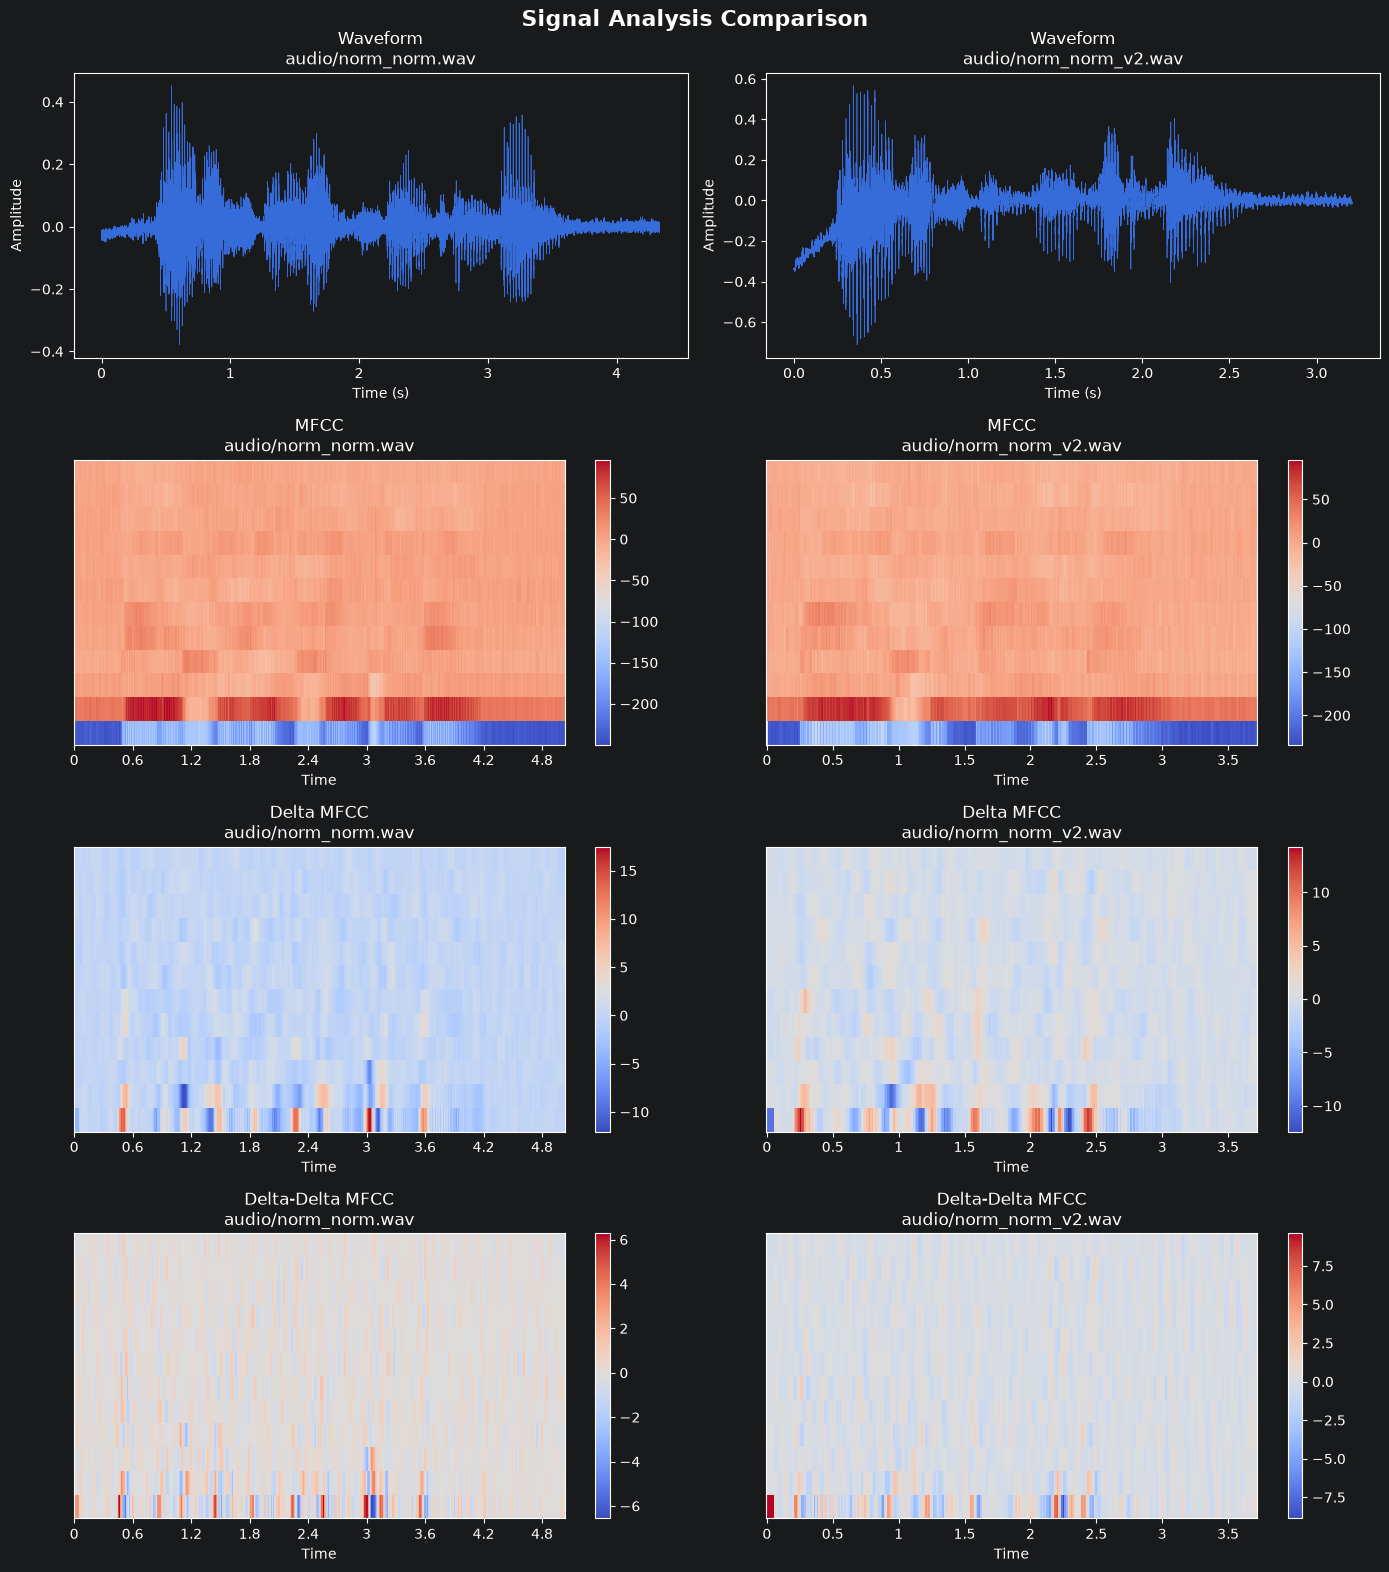

In [17]:
analyse_signals("audio/man.wav", "audio/woman.wav")
analyse_signals("audio/norm_norm.wav", "audio/norm_norm_v2.wav")

### Vprašanja

**Katere značilnice (koeficienti MFCC, delta ali delta-delta) so bolj ponovljive pri istem govorcu, v katerih testnih scenarijih in zakaj?**

O: Statični MFCC koeficienti. Ko ista oseba ponovi isti stavek, je primarna oblika ovojnice signala zelo podobna. Osnovni MFCC koeficienti pa slikajo točno to.

**Katere značilnice (koeficienti MFCC, delta ali delta-delta) se najbolj razlikujejo med različnimi govorci in zakaj?**

O: Statični MFCC koeficienti. Ker delujejo kot reprezentacija akustičnega filtra sistema. Tudi če dva različna vira (govorca) generirata signal z enako časovno poravnavo in enako osnovno frekvenco, se njuni signali razlikujejo v višjih formanith.